#Block 1 Check Point- Choose Your Oscillator 

Required Libraries

In [45]:
import numpy as np
import matplotlib.pyplot as plt

Initial Parameters

In [46]:
# Physical parameters
m = 1.0       # ball mass (kg)
g = 9.81      # gravity (m/s^2)
k = 200.0     # trampoline spring constant (N/m)
b = 2.0       # trampoline damping constant (N·s/m)

# Initial conditions
y0 = 2.0      # initial height above trampoline (m)
v0 = 0.0      # initial velocity (m/s)

# Numerical parameters
dt = 0.001
t_max = 8.0

Simulation:

In [47]:
def simulate_trampoline(m, g, k, b, y0, v0, dt, t_max):

    t = 0.0
    y = y0
    v = v0

    ts = [t]
    ys = [y]
    vs = [v]

    while t < t_max:

        if y > 0:
            # Free fall
            a = -g

        else:
            # Trampoline contact: spring + damping
            a = -g - (k/m)*y - (b/m)*v

        # Euler-Cromer update
        v = v + a * dt
        y = y + v * dt

        t += dt

        ts.append(t)
        ys.append(y)
        vs.append(v)

    return np.array(ts), np.array(ys), np.array(vs)

In [48]:
t, y, v = simulate_trampoline(
    m, g, k, b,
    y0, v0,
    dt, t_max
)

Position Plot: 

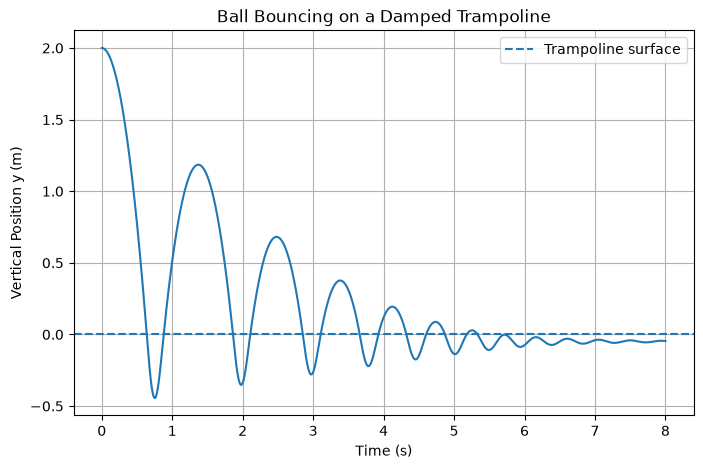

In [49]:
t, y, v = simulate_trampoline(
    m, g, k, b,
    y0, v0,
    dt, t_max
)

plt.figure(figsize=(8,5))

plt.plot(t, y)
plt.axhline(0, linestyle="--", label="Trampoline surface")

plt.xlabel("Time (s)")
plt.ylabel("Vertical Position y (m)")
plt.title("Ball Bouncing on a Damped Trampoline")

plt.legend()
plt.grid()
plt.show()

The plot above shows the position of the ball with respect to time. It matches the expected behavior for a damped ball-trampoline system. The ball starts at 2m which is consistant with the intial parameter for vertical position of the ball above the trampoline if the trampoline is at y=0. The ball then falls under gravity, compresses the trampoline when y<0, and then rebounds upward. Each successive bounce reaches a smaller maximum height because the damping force removes mechanical energy whenever the ball is in contact with the trampoline. As time increases, the oscillations become smaller and the ball approaches an equilibrium position slightly below y=0. That small negative equilibrium position is expected because the trampoline must remain slightly compressed to provide an upward spring force that balances the ball’s weight.


Phase Space Plot:

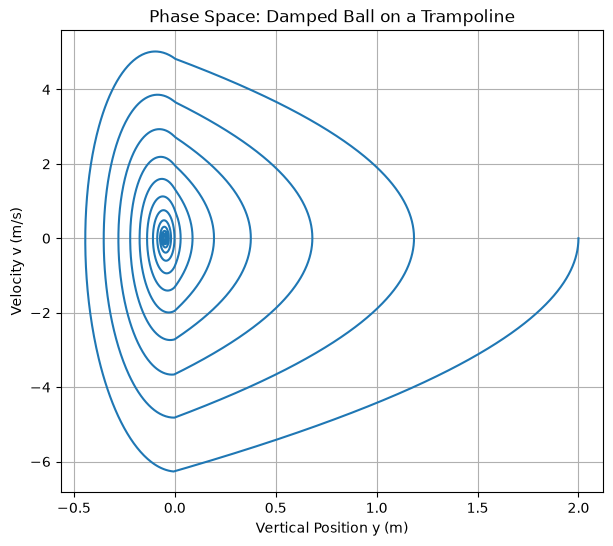

In [50]:
plt.figure(figsize=(7,6))

plt.plot(y, v)

plt.xlabel("Vertical Position y (m)")
plt.ylabel("Velocity v (m/s)")
plt.title("Phase Space: Damped Ball on a Trampoline")

plt.grid()
plt.show()

This phase-space plot also matches the expected behavior of a damped system. It shows the ball’s velocity with respect to its vertical position as the motion happens over time.
The trajectory spirals inward toward the equilibrium region near y=0 and v=0. Each loop represents another bounce. Because damping removes mechanical energy during contact with the trampoline, both the maximum speed and maximum displacement decrease over time, causing the loops to get progressively smaller.
The phase-space curve is not a simple ellipse like you would see with an ideal harmonic oscillator because the motion is piecewise. A simple way to understand what piecewise means is that the kinematics of the ball are different based on the positon of the ball. Aka the ball follows different equations based on whether the ball is in the air or in contact with the trampoline. When the ball is above the trampoline, it is in free fall under gravity, while below y=0 it experiences the spring and damping forces from the trampoline. The inward spiral confirms that the system is losing mechanical energy and eventually settles toward rest, which is exactly what is expected for a damped oscillator.

In [51]:
KE = 0.5 * m * v**2
PE_gravity = m * g * y

PE_spring = np.zeros_like(y)

for i in range(len(y)):
    if y[i] < 0:
        PE_spring[i] = 0.5 * k * y[i]**2

E_mechanical = KE + PE_gravity + PE_spring

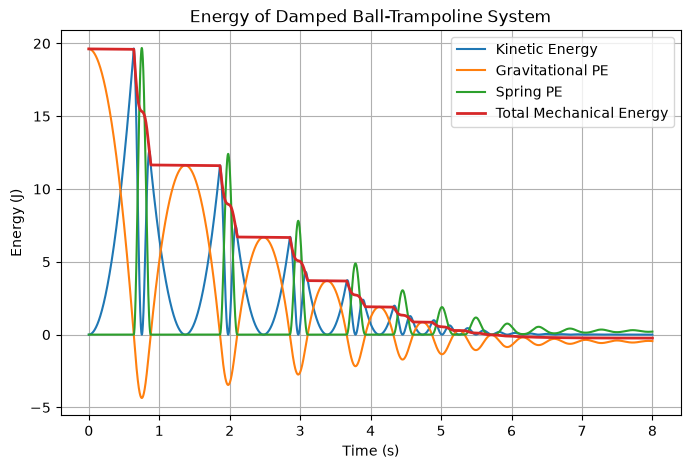

In [52]:
plt.figure(figsize=(8,5))

plt.plot(t, KE, label="Kinetic Energy")
plt.plot(t, PE_gravity, label="Gravitational PE")
plt.plot(t, PE_spring, label="Spring PE")
plt.plot(t, E_mechanical, label="Total Mechanical Energy", linewidth=2)

plt.xlabel("Time (s)")
plt.ylabel("Energy (J)")
plt.title("Energy of Damped Ball-Trampoline System")

plt.legend()
plt.grid()
plt.show()

This plot shows the expected energy behavior for a damped ball-trampoline system. The ball’s energy continuously shifts between kinetic energy, gravitational potential energy, and spring potential energy as it falls, compresses the trampoline, and bounces back. The kinetic energy peaks while the ball is at its highest velocity. The gravitational potential energy is largest near the top of each bounce and decreases as the ball falls. The spring potential energy appears only when the ball compresses the trampoline below its equilibrium position. The curve (which is red) shows the mechanical energy. It decreases after each bounce because the damping force removes energy from the system. The step-like behavior decreases during trampoline contact, since that is when damping occurs. As time goes on, the energy approaches a small value and the oscillations become smaller, which is consistent with the expected behavior of a damped system.

In [53]:
energy_change = E_mechanical[-1] - E_mechanical[0]

print("Initial mechanical energy =", E_mechanical[0], "J")
print("Final mechanical energy =", E_mechanical[-1], "J")
print("Change in mechanical energy =", energy_change, "J")

Initial mechanical energy = 19.62 J
Final mechanical energy = -0.23809464499918648 J
Change in mechanical energy = -19.858094644999188 J


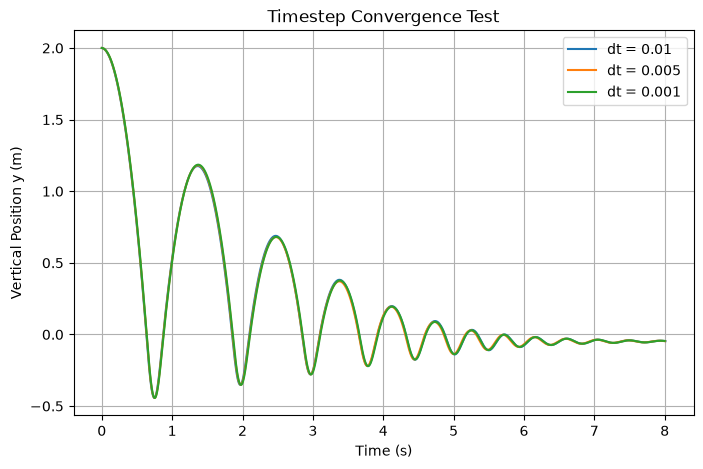

In [54]:
dt_values = [0.01, 0.005, 0.001]

plt.figure(figsize=(8,5))

for dt_test in dt_values:

    t_test, y_test, v_test = simulate_trampoline(
        m, g, k, b,
        y0, v0,
        dt_test, t_max
    )

    plt.plot(t_test, y_test, label=f"dt = {dt_test}")

plt.xlabel("Time (s)")
plt.ylabel("Vertical Position y (m)")
plt.title("Timestep Convergence Test")

plt.legend()
plt.grid()
plt.show()

This convergence test shows that the simulation is numerically stable. The trajectories for dt=0.01, dt=0.005, and dt=0.001 almost completely overlap. This shows that reducing the timestep doesn't significantly change the predicted motion.
The plot also shows what I would expect for damped motion behavior. Each subsequent bounce reaches a lower height than the previous one, and the oscillations gradually die out as energy is dissipated by the trampoline damping. Because the three timestep solutions agree closely throughout the simulation, the chosen Euler-Cromer method is producing a converged result, and dt=0.001 is good enough for this model.

In [55]:
E_dissipated = np.zeros_like(t)

for i in range(1, len(t)):
    if y[i] <= 0:
        E_dissipated[i] = (
            E_dissipated[i-1] +
            b * v[i]**2 * dt
        )
    else:
        E_dissipated[i] = E_dissipated[i-1]

E_check = E_mechanical + E_dissipated

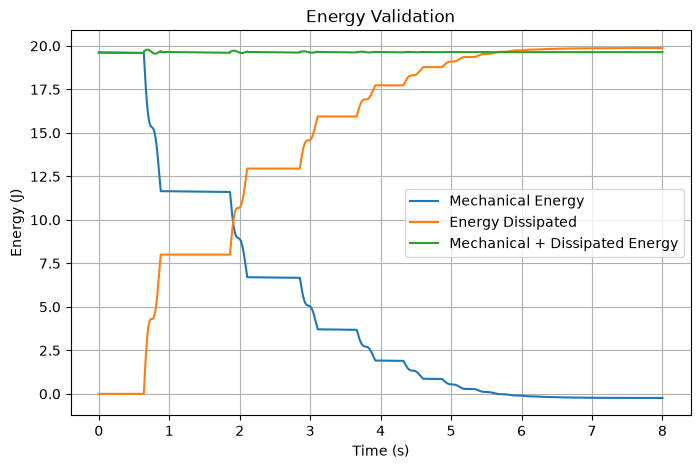

In [56]:
plt.figure(figsize=(8,5))

plt.plot(t, E_mechanical, label="Mechanical Energy")
plt.plot(t, E_dissipated, label="Energy Dissipated")
plt.plot(t, E_check, label="Mechanical + Dissipated Energy")

plt.xlabel("Time (s)")
plt.ylabel("Energy (J)")
plt.title("Energy Validation")

plt.legend()
plt.grid()
plt.show()

The energy plot agrees with the expected physics of a damped trampoline. Mechanical energy decreases whenever the ball contacts the trampoline because the damping force removes energy from the motion. The dissipated energy increases by approximately the same amount. The sum of mechanical and dissipated energy remains nearly constant, showing that the simulation conserves total energy when the energy lost to damping is included. The step-like pattern occurs because damping acts only while the ball is compressing the trampoline.

The simulation models a ball bouncing on a damped trampoline. When the ball is above the trampoline, gravity is the only force acting on it. Once the ball reaches and compresses the trampoline, the forces acting on it change. The trampoline applies both a spring force and a damping force, which pushes the ball back upward while also removing some mechanical energy from the system.

The expected physics is that each bounce should be lower than the one before it because energy is lost through damping. This is shown in the position vs time plot, where the ball starts at 2m and reaches a progressively smaller maximum height after every bounce. Eventually, the motion becomes very small and the ball settles near the trampoline surface. This also matches what I have experienced as a child bouncing a soccer ball against a trampoline which is why I chose this type of simulation. 

The phase-space plot also agrees with the expected behavior. Instead of repeating the same path, the curve moves inward toward y=0 and v=0 which makes sense because the  ball is bounching lower and has less velocity the more energy that is removed from the system because of damping. The energy plots show the same trend: Kinetic, gravitational potential, and spring potential energy are transferred back and forth during each bounce, while the total mechanical energy decreases because of damping. When the dissipated energy is included, the total energy stays nearly constant.

The convergence test also supports the simulation. The results for timesteps of 0.01 s, 0.005 s, and 0.001 s almost completely overlap, showing that decreasing the timestep does not significantly change the result. Overall, the simulation agrees well with the expected physics of a damped ball bouncing on a trampoline.